In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [11]:
df = pd.read_csv('../results/clean_experiment/Deep_Learning/DL_final_experiment_raw.csv')
# df = pd.read_csv('../results/raw_experiment/final_experiment_raw.csv')

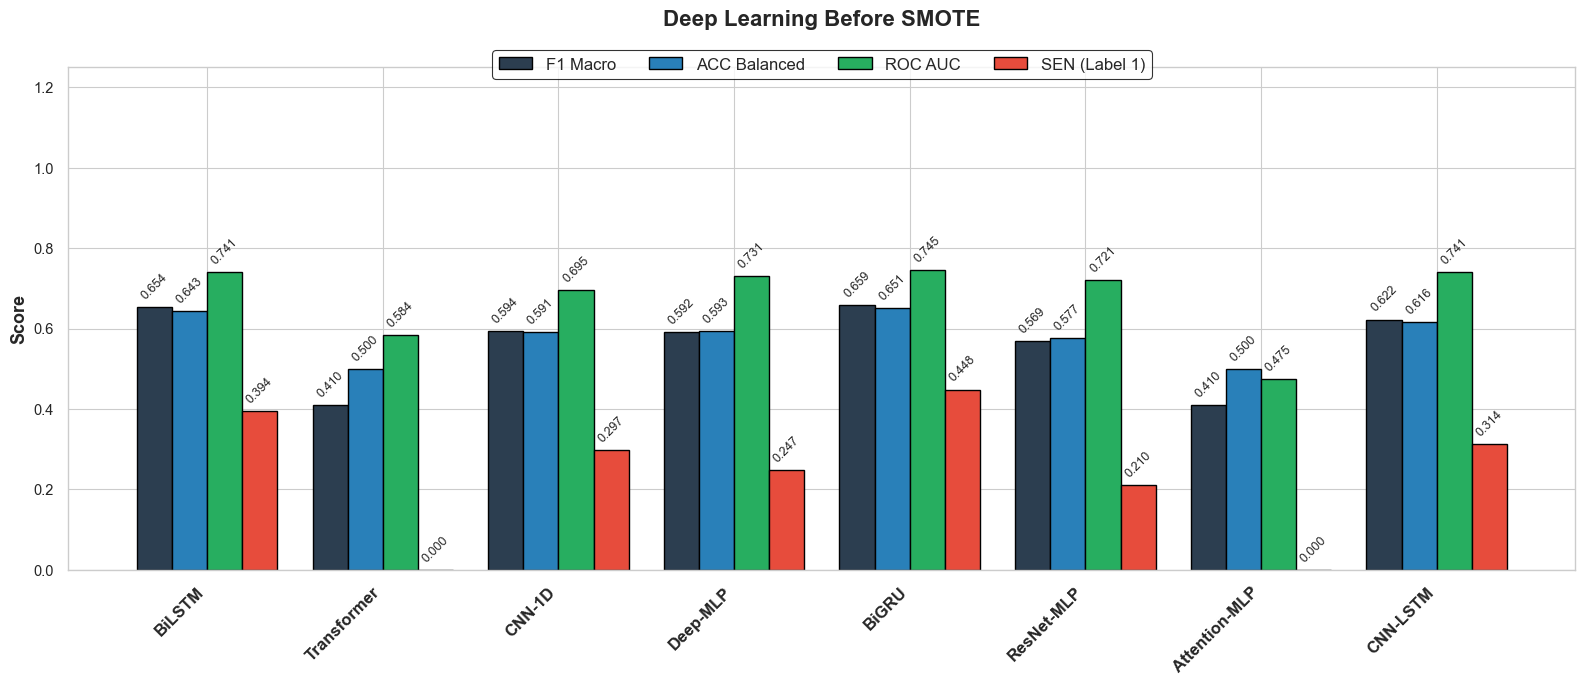

In [12]:
nosmote_df = df[df['Data versioning'].str.contains('nosmote', na=False)]

models = nosmote_df['Model'].unique()

f1_macros = []
acc_balanceds = []
roc_aucs = []
sens = []

for model in models:
    row_0 = nosmote_df[(nosmote_df['Model'] == model) & (nosmote_df['Label'] == 0)]
    f1_macros.append(row_0['F1_macro'].values[0])
    acc_balanceds.append(row_0['ACC balanced'].values[0])
    roc_aucs.append(row_0['ROC_AUC'].values[0])
    
    row_1 = nosmote_df[(nosmote_df['Model'] == model) & (nosmote_df['Label'] == 1)]
    sens.append(row_1['SEN'].values[0])

plt.style.use('seaborn-v0_8-paper')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

x = np.arange(len(models))
width = 0.2  

fig, ax = plt.subplots(figsize=(16, 7))

color_f1 = '#2C3E50'     
color_acc = '#2980B9'   
color_roc = '#27AE60'    
color_sen = '#E74C3C'    

rects1 = ax.bar(x - 1.5*width, f1_macros, width, label='F1 Macro', color=color_f1, edgecolor='black', linewidth=1)
rects2 = ax.bar(x - 0.5*width, acc_balanceds, width, label='ACC Balanced', color=color_acc, edgecolor='black', linewidth=1)
rects3 = ax.bar(x + 0.5*width, roc_aucs, width, label='ROC AUC', color=color_roc, edgecolor='black', linewidth=1)
rects4 = ax.bar(x + 1.5*width, sens, width, label='SEN (Label 1)', color=color_sen, edgecolor='black', linewidth=1)

ax.set_ylabel('Score', fontsize=13, fontweight='bold')
# ax.set_title('Machine Learning Before SMOTE', 
#              fontsize=16, fontweight='bold', pad=30)
ax.set_title('Deep Learning Before SMOTE', 
             fontsize=16, fontweight='bold', pad=30)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.25) 

ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4, fontsize=12, frameon=True, edgecolor='black')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if pd.notna(height) and height >= 0:
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 4),  
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, rotation=45) 

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

plt.tight_layout()

# plt.savefig('Machine_Learning_Before_SMOTE.png', dpi=300, bbox_inches='tight')
plt.savefig('Deep_Learning_Before_SMOTE.png', dpi=300, bbox_inches='tight')
plt.show()

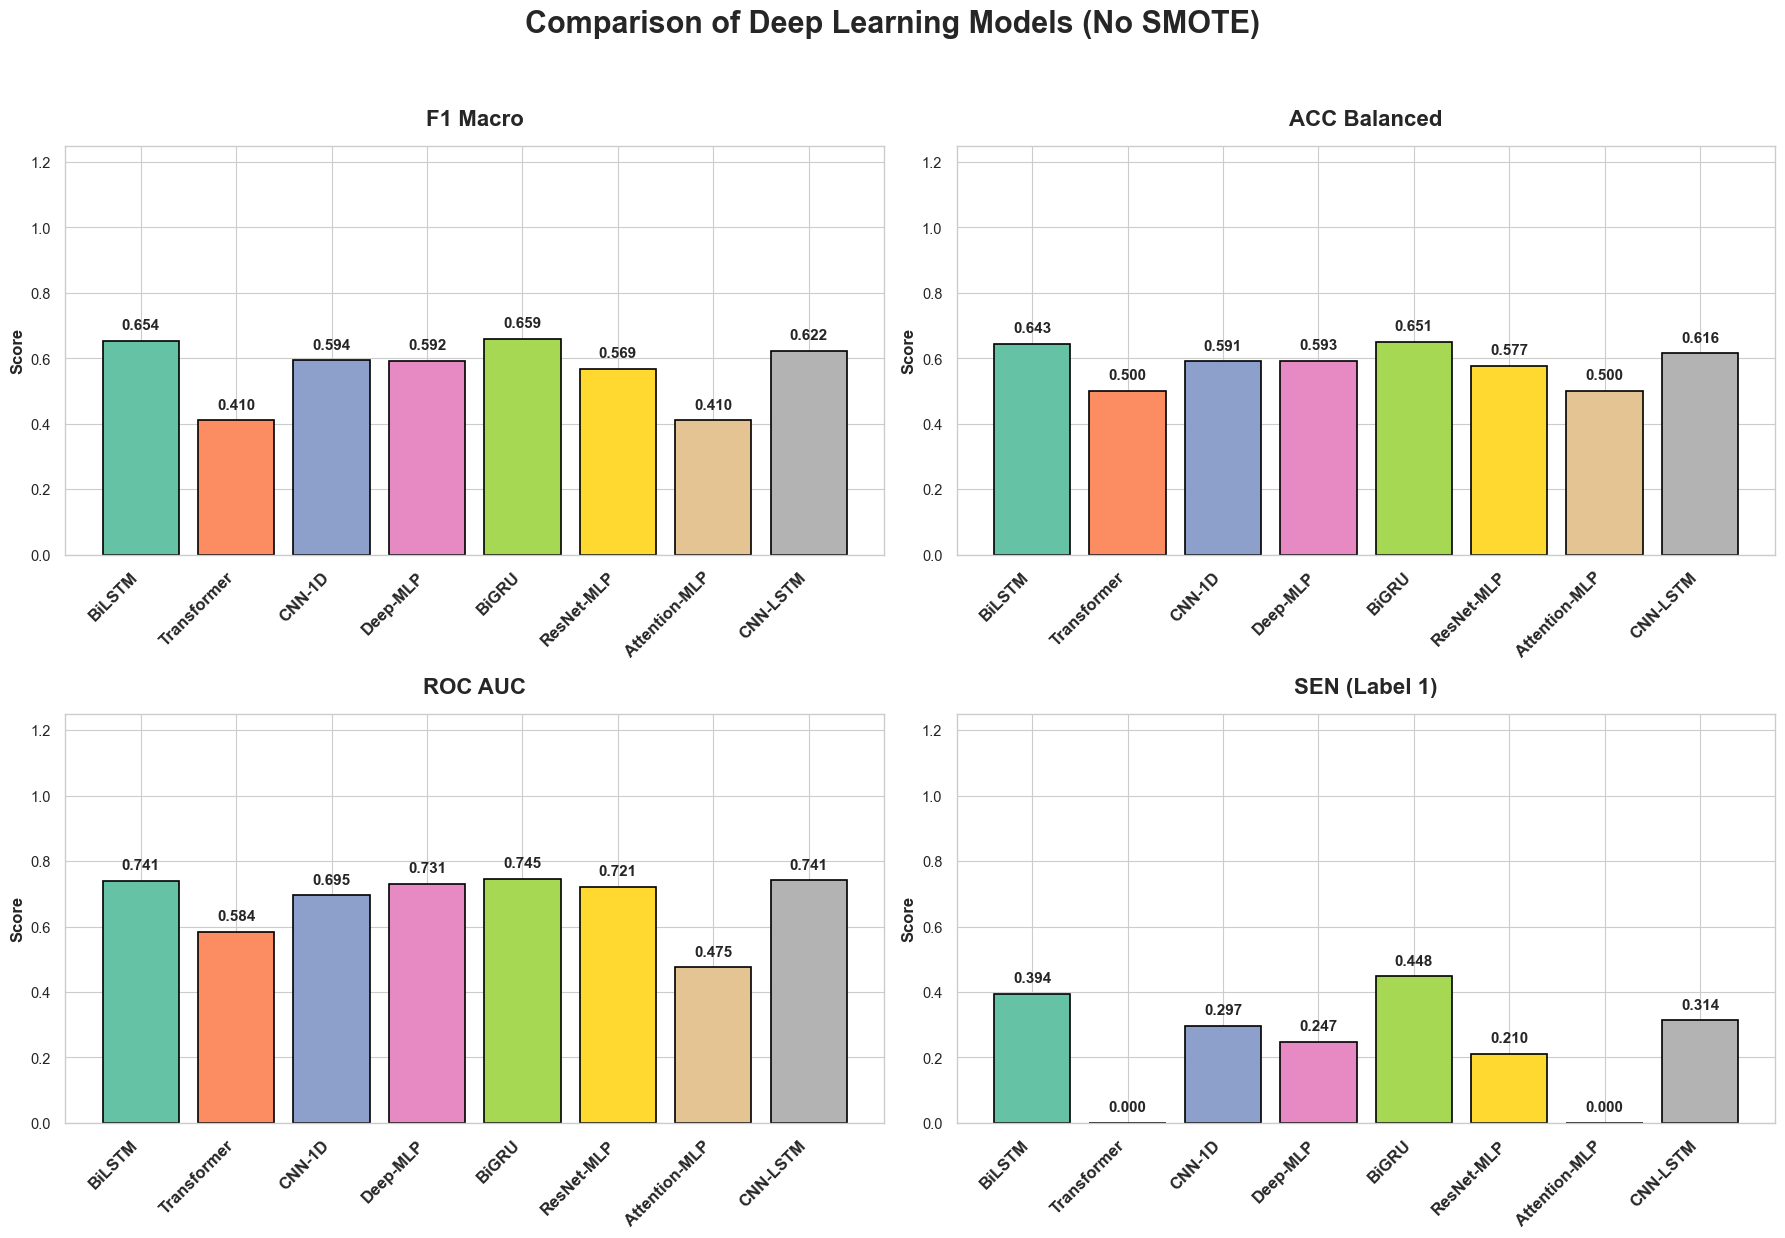

In [13]:
nosmote_df = df[df['Data versioning'].str.contains('nosmote', na=False)]

models = nosmote_df['Model'].unique()

f1_macros = []
acc_balanceds = []
roc_aucs = []
sens = []

for model in models:
    row_0 = nosmote_df[(nosmote_df['Model'] == model) & (nosmote_df['Label'] == 0)]
    f1_macros.append(row_0['F1_macro'].values[0])
    acc_balanceds.append(row_0['ACC balanced'].values[0])
    roc_aucs.append(row_0['ROC_AUC'].values[0])
    
    row_1 = nosmote_df[(nosmote_df['Model'] == model) & (nosmote_df['Label'] == 1)]
    sens.append(row_1['SEN'].values[0])

plt.style.use('seaborn-v0_8-paper')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten() 

metrics = [
    ('F1 Macro', f1_macros),
    ('ACC Balanced', acc_balanceds),
    ('ROC AUC', roc_aucs),
    ('SEN (Label 1)', sens)
]

colors = sns.color_palette("Set2", len(models))

for i, (metric_name, metric_values) in enumerate(metrics):
    ax = axes[i]
    
    bars = ax.bar(models, metric_values, color=colors, edgecolor='black', linewidth=1.2)
    
    ax.set_title(metric_name, fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    
    ax.set_xticks(np.arange(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.25) 
    
    for bar in bars:
        height = bar.get_height()
        if pd.notna(height) and height >= 0:
            ax.annotate(f'{height:.3f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 6),  
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=11, fontweight='bold')

# fig.suptitle('Comparison of Machine Learning Models (No SMOTE)', 
#              fontsize=22, fontweight='bold', y=1.03)
fig.suptitle('Comparison of Deep Learning Models (No SMOTE)', 
             fontsize=22, fontweight='bold', y=1.03)

plt.tight_layout()

# plt.savefig('MC_NoSMOTE_Subplots_2x2.png', dpi=300, bbox_inches='tight')
plt.savefig('DL_NoSMOTE_Subplots_2x2.png', dpi=300, bbox_inches='tight')
plt.show()